# Step 2B — Temporal Feature Distribution Sanity Check

**Goal.** Confirm that the three temporal features (`delta_mean_s`, `delta_std_s`, `delta_min_s`) are heavy-tailed and class-dependent in a way that explains why their removal alone rescues SVM by +0.36 to +0.57 F1.

**What we're testing:**
1. **Heavy tails** — do the temporal features have extreme skewness / kurtosis / high max-to-median ratios? Heavy tails destabilize linear margin learning on small data.
2. **Class separation** — do sock vs non-sock differ in these features? If yes, the features carry signal but the *scale* of the signal damages SVM.
3. **Log-scale recovery** — does `log1p(feature)` produce a well-behaved distribution? If yes, that suggests the original scale is the problem, not the underlying signal.
4. **Counterfactual** — does adding `log1p`-transformed temporal features back to the `drop_temporal` configuration recover signal without breaking SVM?

**If all four check out:** the Ch 5 mechanism claim is supported — heavy-tailed temporal features destabilize linear margins on small data, and the fix is either to remove them or transform them.

**Inputs:** `phase2_{train,test}_exp{1,2,3}.csv`

**Outputs:**
- `step2b_temporal_stats.csv` — per-feature, per-class distribution stats
- `step2b_temporal_distributions.png` — log-scale histograms
- `step2b_log_transform_test.csv` — SVM F1 with raw vs log-transformed temporal features

## Cell 1 — Imports and load all 3 experiments

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, recall_score, precision_score

RANDOM_STATE = 42

TEMPORAL = ['delta_mean_s', 'delta_std_s', 'delta_min_s']

CONTENT_DIMS    = ['political', 'attack', 'emotional', 'low_effort', 'authenticity']
STRUCTURAL_DIMS = ['emoji', 'length', 'repetition', 'punctuation', 'caps']
COORD_DIMS      = ['coordination', 'algorithmic']
AGGS = ['mean', 'max', 'std', 'sum']
expand = lambda dims: [f'{d}_{a}' for d in dims for a in AGGS]

L_CONTENT    = expand(CONTENT_DIMS)
L_STRUCTURAL = expand(STRUCTURAL_DIMS)
L_COORD_NON_TEMPORAL = (expand(COORD_DIMS)
                       + ['overall_max', 'overall_mean', 'n_high_score', 'n_med_score']
                       + ['n_comments', 'n_threads', 'likes_total', 'likes_per_comment',
                          'threads_per_comment', 'likes_mean', 'replies_mean'])

# Merge all 3 experiments for distribution analysis (deduplicate by user_id, keep first label)
frames = []
for e in (1, 2, 3):
    for sp in ('train', 'test'):
        df = pd.read_csv(f'../phase2_{sp}_exp{e}.csv')
        df['exp'] = e
        df['split'] = sp
        frames.append(df)
all_users = pd.concat(frames, ignore_index=True).drop_duplicates(subset='user_id', keep='first')
print(f'Total unique users: {len(all_users)}  (sock={int(all_users.label.sum())})')
all_users[TEMPORAL].describe().round(2)


Total unique users: 280  (sock=140)


,delta_mean_s,delta_std_s,delta_min_s
count,280.00,280.00,280.00
mean,78420.55,75163.86,22169.48
std,158261.60,130614.56,100739.08
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,9270.62,3274.41,48.50
75%,77711.95,105389.04,217.25
max,865422.00,837359.50,865422.00


## Cell 2 — Distribution statistics (heavy-tail check)

In [3]:
rows = []
for feat in TEMPORAL:
    for cls, label in (('sock', 1), ('non-sock', 0)):
        v = all_users[all_users.label == label][feat].values
        v_pos = v[v > 0]  # for max/median ratio
        rows.append({
            'feature':       feat,
            'class':         cls,
            'n':             len(v),
            'mean':          v.mean(),
            'median':        float(np.median(v)),
            'std':           v.std(ddof=0),
            'max':           v.max(),
            'p99':           float(np.percentile(v, 99)),
            'p95':           float(np.percentile(v, 95)),
            'skewness':      float(stats.skew(v)),
            'kurtosis':      float(stats.kurtosis(v)),
            'max_over_med':  (v.max() / np.median(v_pos)) if len(v_pos) and np.median(v_pos) > 0 else np.nan,
            'zero_frac':     float((v == 0).mean()),
        })
stats_df = pd.DataFrame(rows)
stats_df.to_csv('step2b_temporal_stats.csv', index=False)

# Print compactly
print('Per-feature, per-class distribution stats:')
for feat in TEMPORAL:
    print(f'\n{feat}:')
    sub = stats_df[stats_df.feature == feat]
    print(sub[['class','n','median','mean','max','p95','p99','skewness','kurtosis','max_over_med','zero_frac']]
          .round(2).to_string(index=False))


Per-feature, per-class distribution stats:

delta_mean_s:
   class   n   median      mean       max       p95       p99  skewness  kurtosis  max_over_med  zero_frac
    sock 140   166.62  49746.92 865422.00 230539.42 799443.49      4.46     22.04        118.03       0.33
non-sock 140 33154.12 107094.18 818824.33 535328.35 782277.43      2.41      5.59         14.04       0.21

delta_std_s:
   class   n  median     mean       max       p95       p99  skewness  kurtosis  max_over_med  zero_frac
    sock 140    38.3 54007.90 837359.50 256596.37 628431.42      3.64     16.13         24.04       0.46
non-sock 140 50235.6 96319.82 687374.01 363204.10 593745.34      2.09      4.86          7.55       0.29

delta_min_s:
   class   n  median     mean      max      p95       p99  skewness  kurtosis  max_over_med  zero_frac
    sock 140    34.5  8138.96 865422.0   1510.2 132497.97     11.02    123.37      10121.89       0.33
non-sock 140    69.0 36200.00 695165.0 287699.5 571796.07      3.83     

## Cell 3 — Visualize: raw vs log scale, by class

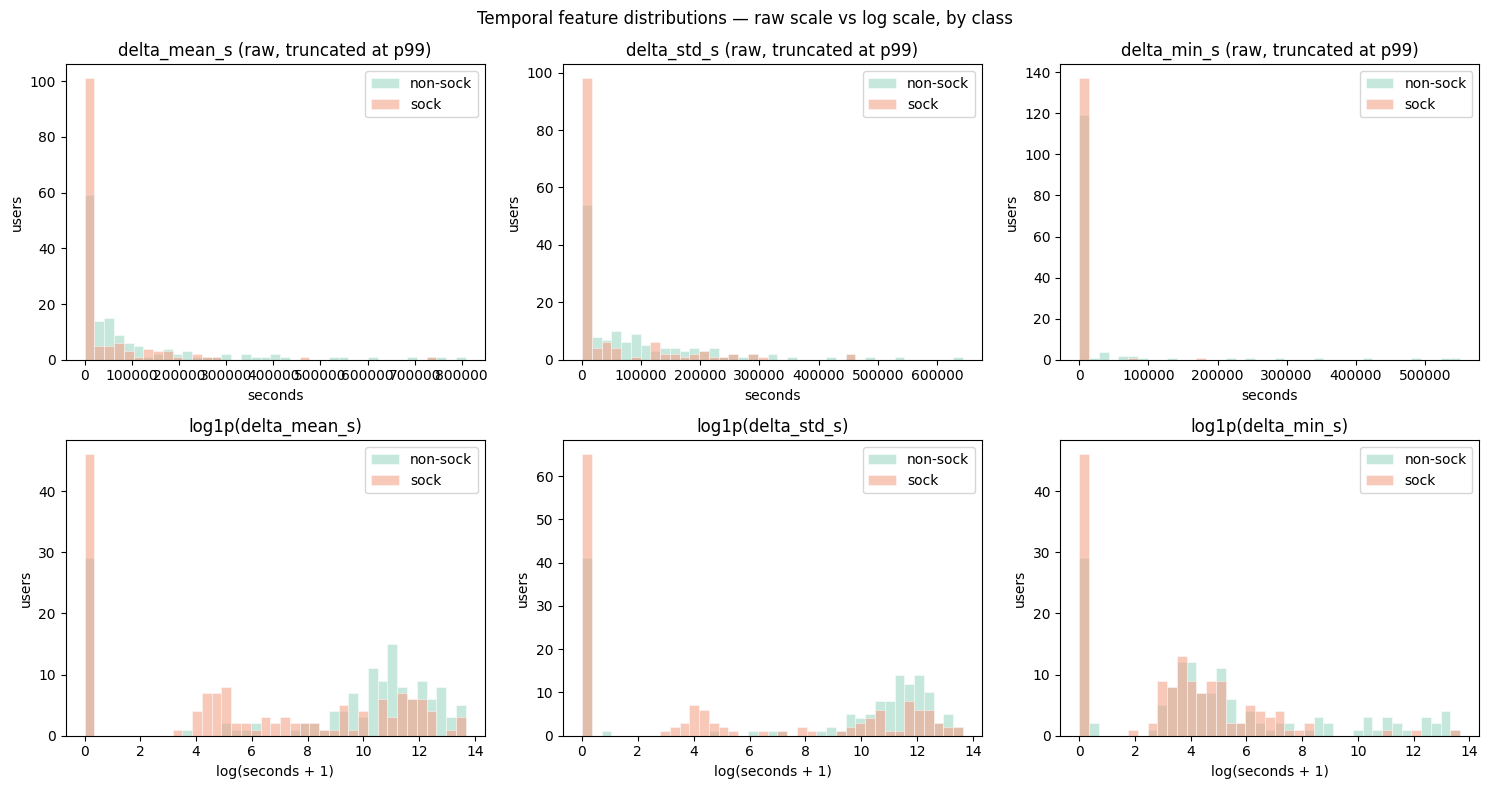

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col_idx, feat in enumerate(TEMPORAL):
    sock_vals     = all_users[all_users.label == 1][feat].values
    non_sock_vals = all_users[all_users.label == 0][feat].values

    # Top row: raw scale (truncated to 99th percentile for readability)
    ax = axes[0, col_idx]
    cutoff = np.percentile(np.concatenate([sock_vals, non_sock_vals]), 99)
    bins = np.linspace(0, cutoff, 40)
    ax.hist(non_sock_vals[non_sock_vals <= cutoff], bins=bins, alpha=0.6,
            label='non-sock', color='#9fd8c5', edgecolor='white', linewidth=0.5)
    ax.hist(sock_vals[sock_vals <= cutoff], bins=bins, alpha=0.6,
            label='sock', color='#f4a48b', edgecolor='white', linewidth=0.5)
    ax.set_title(f'{feat} (raw, truncated at p99)')
    ax.set_xlabel('seconds')
    ax.set_ylabel('users')
    ax.legend()

    # Bottom row: log1p scale (full range)
    ax = axes[1, col_idx]
    log_sock     = np.log1p(sock_vals)
    log_non_sock = np.log1p(non_sock_vals)
    bins = np.linspace(0, max(log_sock.max(), log_non_sock.max()), 40)
    ax.hist(log_non_sock, bins=bins, alpha=0.6,
            label='non-sock', color='#9fd8c5', edgecolor='white', linewidth=0.5)
    ax.hist(log_sock, bins=bins, alpha=0.6,
            label='sock', color='#f4a48b', edgecolor='white', linewidth=0.5)
    ax.set_title(f'log1p({feat})')
    ax.set_xlabel('log(seconds + 1)')
    ax.set_ylabel('users')
    ax.legend()

fig.suptitle('Temporal feature distributions — raw scale vs log scale, by class', fontsize=12)
plt.tight_layout()
plt.savefig('step2b_temporal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 4 — Counterfactual: does log1p transformation rescue SVM?

In [6]:
def metrics(y_true, y_pred):
    return {'recall': recall_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0)}

def svm_run(Xtr, ytr, Xte, yte):
    svm = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000).fit(Xtr, ytr)
    return metrics(yte, svm.predict(Xte))

rows = []
for exp_id in (1, 2, 3):
    tr = pd.read_csv(f'../phase2_train_exp{exp_id}.csv')
    te = pd.read_csv(f'../phase2_test_exp{exp_id}.csv')
    ytr, yte = tr['label'].values, te['label'].values

    # 4 configurations to compare:
    # (a) full        — all 62 features (Week 1 baseline; SVM collapses)
    # (b) drop_temp   — remove the 3 temporal features (Step 2 finding; SVM rescued)
    # (c) full_logtmp — full set but with log1p(temporal) instead of raw temporal
    # (d) drop_coord  — Week 1 drop_coordination reference

    cols_full     = L_CONTENT + L_STRUCTURAL + L_COORD_NON_TEMPORAL + TEMPORAL
    cols_droptemp = L_CONTENT + L_STRUCTURAL + L_COORD_NON_TEMPORAL
    cols_dropall  = L_CONTENT + L_STRUCTURAL

    Xtr_full = tr[cols_full].values.copy()
    Xte_full = te[cols_full].values.copy()

    Xtr_drt  = tr[cols_droptemp].values.copy()
    Xte_drt  = te[cols_droptemp].values.copy()

    Xtr_da   = tr[cols_dropall].values.copy()
    Xte_da   = te[cols_dropall].values.copy()

    # log-transformed temporal version of full
    tr_log = tr.copy(); te_log = te.copy()
    for c in TEMPORAL:
        tr_log[c] = np.log1p(tr[c].clip(lower=0))
        te_log[c] = np.log1p(te[c].clip(lower=0))
    Xtr_log = tr_log[cols_full].values
    Xte_log = te_log[cols_full].values

    for name, Xtr, Xte in [('full',       Xtr_full, Xte_full),
                            ('drop_temp',  Xtr_drt,  Xte_drt),
                            ('full_logtmp',Xtr_log,  Xte_log),
                            ('drop_coord_all', Xtr_da, Xte_da)]:
        m = svm_run(Xtr, ytr, Xte, yte)
        rows.append({'experiment': exp_id, 'config': name,
                     'n_features': Xtr.shape[1], **m})

logres = pd.DataFrame(rows)
logres.to_csv('step2b_log_transform_test.csv', index=False)

pivot = logres.pivot(index='experiment', columns='config', values='f1') \
              .reindex(columns=['full', 'drop_temp', 'full_logtmp', 'drop_coord_all']) \
              .round(4)
print('SVM F1 comparison:')
print(pivot.to_string())

print('\nInterpretation:')
print('  - If full_logtmp ≈ drop_temp: log transform alone fixes SVM (signal recoverable)')
print('  - If full_logtmp ≈ full:      removing temporal is the only fix (raw scale is uninformative for SVM)')
print('  - If full_logtmp between:     log helps partially')


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_class

SVM F1 comparison:
config        full  drop_temp  full_logtmp  drop_coord_all
experiment                                                
1           0.2443     0.6040       0.6537          0.6527
2           0.3429     0.6826       0.7160          0.6923
3           0.1351     0.7071       0.7600          0.6535

Interpretation:
  - If full_logtmp ≈ drop_temp: log transform alone fixes SVM (signal recoverable)
  - If full_logtmp ≈ full:      removing temporal is the only fix (raw scale is uninformative for SVM)
  - If full_logtmp between:     log helps partially


/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/Ken/anaconda3/envs/SiMAIM_TGIF_2/lib/python3.10/site-packages/sklearn/svm/_base.

## Cell 5 — Summary

In [7]:
lines = []
lines.append('=' * 70)
lines.append('STEP 2B SUMMARY — Temporal Feature Sanity Check')
lines.append('=' * 70)
lines.append('')

# 1. Heavy tail check
lines.append('1. Heavy-tail evidence:')
for feat in TEMPORAL:
    skew_sock = float(stats_df[(stats_df.feature==feat) & (stats_df["class"]=="sock")]["skewness"].iloc[0])
    skew_non  = float(stats_df[(stats_df.feature==feat) & (stats_df["class"]=="non-sock")]["skewness"].iloc[0])
    mx_med_s  = stats_df[(stats_df.feature==feat) & (stats_df["class"]=="sock")]["max_over_med"].iloc[0]
    mx_med_n  = stats_df[(stats_df.feature==feat) & (stats_df["class"]=="non-sock")]["max_over_med"].iloc[0]
    is_heavy = (skew_sock > 2) or (skew_non > 2) or (
        (not np.isnan(mx_med_s) and mx_med_s > 100) or
        (not np.isnan(mx_med_n) and mx_med_n > 100))
    flag = '✓ heavy-tailed' if is_heavy else '— not heavy'
    lines.append(f'   {feat}: skew sock={skew_sock:.1f}, non={skew_non:.1f}; '
                 f'max/med sock={mx_med_s:.1f}, non={mx_med_n:.1f}   {flag}')
lines.append('')

# 2. Log transform result
lines.append('2. log1p transform vs raw temporal (SVM F1):')
mean_full   = logres[logres.config=='full']['f1'].mean()
mean_drop   = logres[logres.config=='drop_temp']['f1'].mean()
mean_logtmp = logres[logres.config=='full_logtmp']['f1'].mean()

lines.append(f'   mean across 3 exps:  full={mean_full:.3f}  drop_temp={mean_drop:.3f}  '
             f'full_logtmp={mean_logtmp:.3f}')

# Position of full_logtmp between full and drop_temp
if mean_drop > mean_full:
    recovery = (mean_logtmp - mean_full) / (mean_drop - mean_full)
    lines.append(f'   log1p recovers {recovery*100:.0f}% of the rescue gap.')
    if recovery > 0.7:
        lines.append('   → Log transform alone fixes SVM. The temporal signal is recoverable.')
        verdict = 'log_fixes_it'
    elif recovery > 0.3:
        lines.append('   → Log transform helps but does not fully fix SVM.')
        verdict = 'log_helps_partially'
    else:
        lines.append('   → Log transform does NOT fix SVM. Removal is the only fix.')
        verdict = 'log_does_not_help'
else:
    lines.append('   → Drop_temp did not improve over full in this run; cannot evaluate.')
    verdict = 'inconclusive'
lines.append('')

# 3. Implication for thesis
lines.append('3. Implication for Ch 5:')
if verdict == 'log_fixes_it':
    lines.append('   The temporal features carry signal; the raw seconds scale is what destabilizes')
    lines.append('   SVM. log1p preprocessing recovers utility while keeping the features. This is')
    lines.append('   a methodological recommendation: scale-aware preprocessing of temporal features.')
elif verdict == 'log_does_not_help':
    lines.append('   The temporal features themselves are not useful — log scaling does not recover')
    lines.append('   signal. Removal is the right intervention.')
else:
    lines.append('   Partial recovery via log transform. Removal remains the more reliable fix,')
    lines.append('   but log scaling is a softer alternative worth mentioning.')

txt = '\n'.join(lines)
print(txt)


STEP 2B SUMMARY — Temporal Feature Sanity Check

1. Heavy-tail evidence:
   delta_mean_s: skew sock=4.5, non=2.4; max/med sock=118.0, non=14.0   ✓ heavy-tailed
   delta_std_s: skew sock=3.6, non=2.1; max/med sock=24.0, non=7.5   ✓ heavy-tailed
   delta_min_s: skew sock=11.0, non=3.8; max/med sock=10121.9, non=4895.5   ✓ heavy-tailed

2. log1p transform vs raw temporal (SVM F1):
   mean across 3 exps:  full=0.241  drop_temp=0.665  full_logtmp=0.710
   log1p recovers 111% of the rescue gap.
   → Log transform alone fixes SVM. The temporal signal is recoverable.

3. Implication for Ch 5:
   The temporal features carry signal; the raw seconds scale is what destabilizes
   SVM. log1p preprocessing recovers utility while keeping the features. This is
   a methodological recommendation: scale-aware preprocessing of temporal features.


## Done

Three outputs:
- `step2b_temporal_stats.csv` — per-feature, per-class distribution stats
- `step2b_temporal_distributions.png` — raw + log-scale histograms
- `step2b_log_transform_test.csv` — SVM F1 with raw vs log-transformed temporal features

Runtime: <30 seconds. No GPU, no GridSearch.

**What to look for:**
- Cell 2 stats: skew > 2 and max/median > 100 → heavy tails confirmed.
- Cell 3 plot: raw histograms heavily right-skewed, log histograms approximately normal.
- Cell 4 counterfactual: if `full_logtmp` ≈ `drop_temp`, the mechanism is *scale*, not *content*. That's a methodological recommendation (preprocess temporal features) rather than a removal recommendation.

Cell 5 prints the verdict and the thesis implication. After this, go to Ch 5 drafting.